# Упражнения 6.9, 6.10. Ветреный сеточный мир: ходы короля и стохастический ветер

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 6 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch06.pdf).


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [48]:
ROWS = 7
COLS = 10

START = (3, 0)
GOAL = (3, 7)

WIND = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
ALPHA = 0.5
EPS = 0.1
GAMMA = 1

NUM_EPISODES = 2000

## Исходный вариант задачи

In [8]:
ACTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1)]
Q = np.zeros((ROWS, COLS, len(ACTIONS)))
Q.shape

(7, 10, 4)

In [49]:
def step(state, action):
    r, c = state
    dr, dc = action
    wind = WIND[c]                          
    new_r = r + dr - wind                   
    new_c = c + dc
    new_r = max(0, min(ROWS - 1, new_r))
    new_c = max(0, min(COLS - 1, new_c))
    return (new_r, new_c)

def eps_greedy_action(Q, state):
    if random.random() < EPS:
        action_idx = np.random.randint(len(ACTIONS))
    else:
        q_vals = Q[state[0], state[1], :]
        best = np.flatnonzero(q_vals == q_vals.max())
        action_idx = np.random.choice(best)
    return ACTIONS[action_idx], action_idx

def greedy_action(Q, state):
    q_vals = Q[state[0], state[1], :]
    best = np.flatnonzero(q_vals == q_vals.max())
    action_idx = np.random.choice(best)
    return ACTIONS[action_idx], action_idx

Эпизод:   0%|          | 0/2000 [00:00<?, ?it/s]

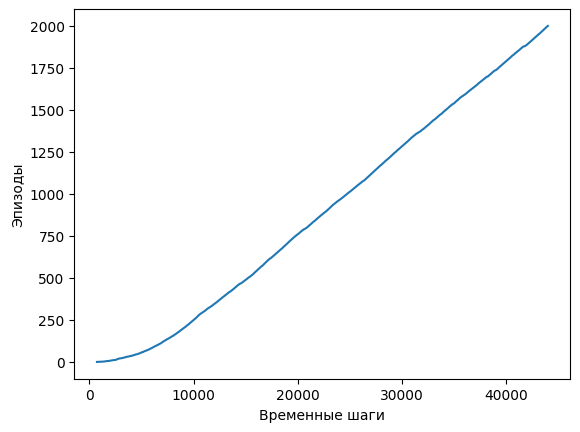

In [10]:
episode_endings = []  
cur_step = 0

for i in tqdm(range(NUM_EPISODES), desc="Эпизод"):
    cur_state = START
    action, action_idx = eps_greedy_action(Q, cur_state)
    while cur_state != GOAL:
        next_state = step(cur_state, action)
        r = -1
        next_action, next_action_idx = eps_greedy_action(Q, next_state)
        Q[cur_state[0], cur_state[1], action_idx] += ALPHA*(
            r + GAMMA*Q[next_state[0], next_state[1], next_action_idx]
            - Q[cur_state[0], cur_state[1], action_idx]
        )
        cur_state = next_state
        action = next_action
        action_idx = next_action_idx
        cur_step += 1
    episode_endings.append(cur_step)

plt.plot(episode_endings, np.arange(1, NUM_EPISODES + 1))
plt.xlabel("Временные шаги")
plt.ylabel("Эпизоды")
plt.show()


Длина жадного пути: 15 шагов


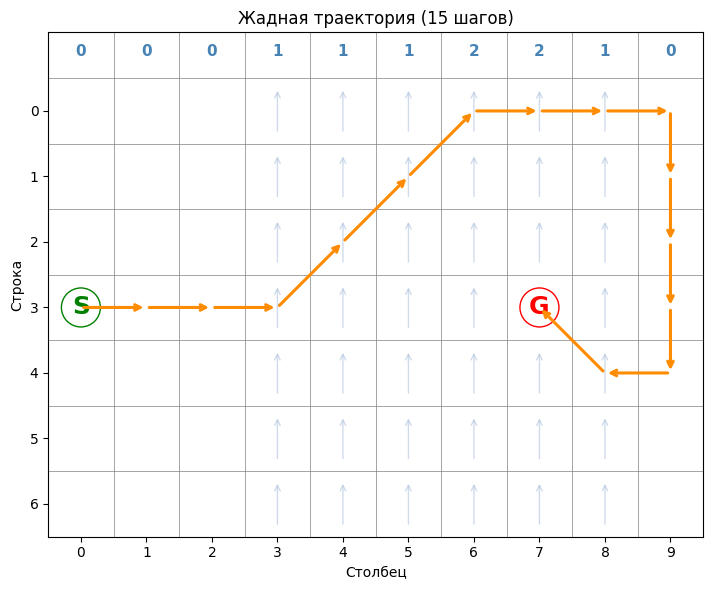

In [11]:
def greedy_trajectory(Q, start, goal, max_steps=200):
    path = [start]
    cur_state = start
    for _ in range(max_steps):
        if cur_state == goal:
            break
        action, _ = greedy_action(Q, cur_state)
        cur_state = step(cur_state, action)
        path.append(cur_state)
    return path

path = greedy_trajectory(Q, START, GOAL)
print(f"Длина жадного пути: {len(path) - 1} шагов")

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -1.2)
ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
ax.set_xticks(range(COLS))
ax.set_yticks(range(ROWS))
ax.grid(which='minor', color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.tick_params(which='minor', length=0)

for c, w in enumerate(WIND):
    if w > 0:
        for r in range(ROWS):
            ax.annotate('', xy=(c, r - 0.35), xytext=(c, r + 0.35),
                        arrowprops=dict(arrowstyle='->', color='lightsteelblue', alpha=0.6))

for c, w in enumerate(WIND):
    ax.text(c, -0.9, str(w), ha='center', va='center',
            fontsize=11, color='steelblue', fontweight='bold')

ax.text(START[1], START[0], 'S', ha='center', va='center',
        fontsize=18, fontweight='bold', color='green',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='green'))
ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center',
        fontsize=18, fontweight='bold', color='red',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='red'))

for i in range(len(path) - 1):
    r1, c1 = path[i]
    r2, c2 = path[i + 1]
    ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))

ax.set_title(f"Жадная траектория ({len(path) - 1} шагов)")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")
plt.tight_layout()
plt.show()

## Упражнение 6.9

## С добавлением диагональных действий

In [12]:
ACTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1), (1, 1), (-1, -1), (1, -1), (-1, 1)]
Q = np.zeros((ROWS, COLS, len(ACTIONS)))
Q.shape

(7, 10, 8)

Эпизод:   0%|          | 0/2000 [00:00<?, ?it/s]

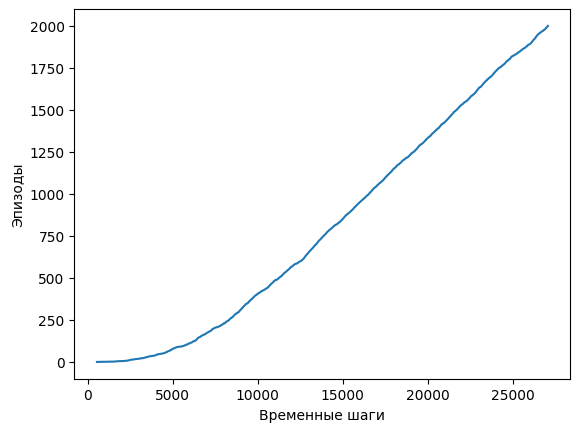

In [13]:
episode_endings = []  
cur_step = 0

for i in tqdm(range(NUM_EPISODES), desc="Эпизод"):
    cur_state = START
    action, action_idx = eps_greedy_action(Q, cur_state)
    while cur_state != GOAL:
        next_state = step(cur_state, action)
        r = -1
        next_action, next_action_idx = eps_greedy_action(Q, next_state)
        Q[cur_state[0], cur_state[1], action_idx] += ALPHA*(
            r + GAMMA*Q[next_state[0], next_state[1], next_action_idx]
            - Q[cur_state[0], cur_state[1], action_idx]
        )
        cur_state = next_state
        action = next_action
        action_idx = next_action_idx
        cur_step += 1
    episode_endings.append(cur_step)

plt.plot(episode_endings, np.arange(1, NUM_EPISODES + 1))
plt.xlabel("Временные шаги")
plt.ylabel("Эпизоды")
plt.show()


Длина жадного пути: 7 шагов


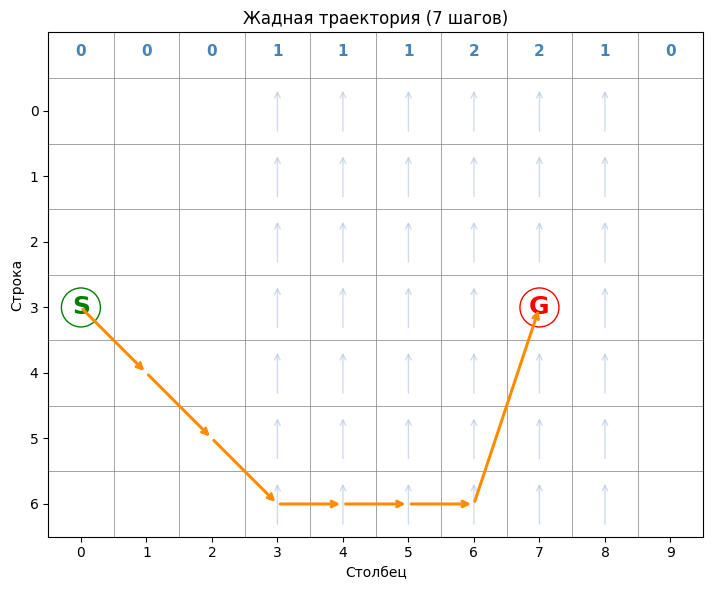

In [14]:
def greedy_trajectory(Q, start, goal, max_steps=200):
    path = [start]
    cur_state = start
    for _ in range(max_steps):
        if cur_state == goal:
            break
        action, _ = greedy_action(Q, cur_state)
        cur_state = step(cur_state, action)
        path.append(cur_state)
    return path

path = greedy_trajectory(Q, START, GOAL)
print(f"Длина жадного пути: {len(path) - 1} шагов")

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -1.2)
ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
ax.set_xticks(range(COLS))
ax.set_yticks(range(ROWS))
ax.grid(which='minor', color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.tick_params(which='minor', length=0)

for c, w in enumerate(WIND):
    if w > 0:
        for r in range(ROWS):
            ax.annotate('', xy=(c, r - 0.35), xytext=(c, r + 0.35),
                        arrowprops=dict(arrowstyle='->', color='lightsteelblue', alpha=0.6))

for c, w in enumerate(WIND):
    ax.text(c, -0.9, str(w), ha='center', va='center',
            fontsize=11, color='steelblue', fontweight='bold')

ax.text(START[1], START[0], 'S', ha='center', va='center',
        fontsize=18, fontweight='bold', color='green',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='green'))
ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center',
        fontsize=18, fontweight='bold', color='red',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='red'))

for i in range(len(path) - 1):
    r1, c1 = path[i]
    r2, c2 = path[i + 1]
    ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))

ax.set_title(f"Жадная траектория ({len(path) - 1} шагов)")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")
plt.tight_layout()
plt.show()

## С добавлением диагональных и "стоячего" действий

In [15]:
ACTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1), (1, 1), (-1, -1), (1, -1), (-1, 1), (0, 0)]
Q = np.zeros((ROWS, COLS, len(ACTIONS)))
Q.shape

(7, 10, 9)

Эпизод:   0%|          | 0/2000 [00:00<?, ?it/s]

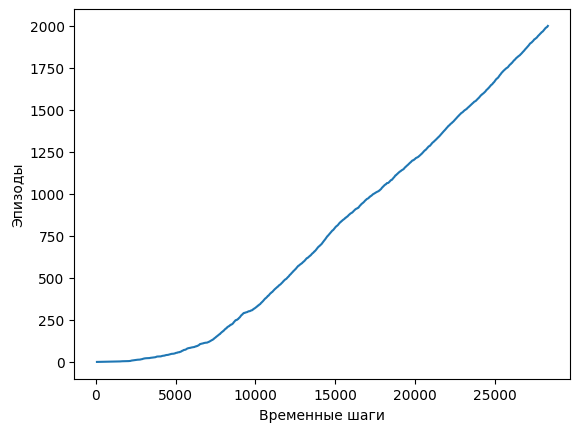

In [16]:
episode_endings = []  
cur_step = 0

for i in tqdm(range(NUM_EPISODES), desc="Эпизод"):
    cur_state = START
    action, action_idx = eps_greedy_action(Q, cur_state)
    while cur_state != GOAL:
        next_state = step(cur_state, action)
        r = -1
        next_action, next_action_idx = eps_greedy_action(Q, next_state)
        Q[cur_state[0], cur_state[1], action_idx] += ALPHA*(
            r + GAMMA*Q[next_state[0], next_state[1], next_action_idx]
            - Q[cur_state[0], cur_state[1], action_idx]
        )
        cur_state = next_state
        action = next_action
        action_idx = next_action_idx
        cur_step += 1
    episode_endings.append(cur_step)

plt.plot(episode_endings, np.arange(1, NUM_EPISODES + 1))
plt.xlabel("Временные шаги")
plt.ylabel("Эпизоды")
plt.show()

Длина жадного пути: 7 шагов


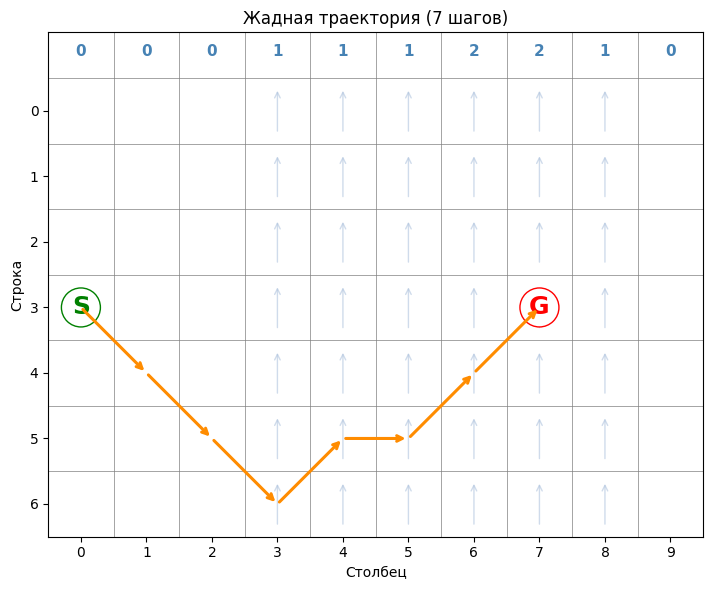

In [17]:
def greedy_trajectory(Q, start, goal, max_steps=200):
    path = [start]
    cur_state = start
    for _ in range(max_steps):
        if cur_state == goal:
            break
        action, _ = greedy_action(Q, cur_state)
        cur_state = step(cur_state, action)
        path.append(cur_state)
    return path

path = greedy_trajectory(Q, START, GOAL)
print(f"Длина жадного пути: {len(path) - 1} шагов")

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -1.2)
ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
ax.set_xticks(range(COLS))
ax.set_yticks(range(ROWS))
ax.grid(which='minor', color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.tick_params(which='minor', length=0)

for c, w in enumerate(WIND):
    if w > 0:
        for r in range(ROWS):
            ax.annotate('', xy=(c, r - 0.35), xytext=(c, r + 0.35),
                        arrowprops=dict(arrowstyle='->', color='lightsteelblue', alpha=0.6))

for c, w in enumerate(WIND):
    ax.text(c, -0.9, str(w), ha='center', va='center',
            fontsize=11, color='steelblue', fontweight='bold')

ax.text(START[1], START[0], 'S', ha='center', va='center',
        fontsize=18, fontweight='bold', color='green',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='green'))
ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center',
        fontsize=18, fontweight='bold', color='red',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='red'))

for i in range(len(path) - 1):
    r1, c1 = path[i]
    r2, c2 = path[i + 1]
    ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))

ax.set_title(f"Жадная траектория ({len(path) - 1} шагов)")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")
plt.tight_layout()
plt.show()

## Упражнение 6.10

In [50]:
NUM_EPISODES = 2000
ACTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1),
           (1, 1), (-1, -1), (1, -1), (-1, 1)]
Q = np.zeros((ROWS, COLS, len(ACTIONS)))
Q.shape

(7, 10, 8)

In [51]:
def step(state, action):
    r, c = state
    dr, dc = action
    wind = WIND[c]
    if wind > 0:
        u = random.random()
        if u < 1/3:
            wind += 1
        elif u < 2/3:
            wind -= 1
    new_r = r + dr - wind
    new_c = c + dc
    new_r = max(0, min(ROWS - 1, new_r))
    new_c = max(0, min(COLS - 1, new_c))
    return (new_r, new_c)

Эпизод:   0%|          | 0/2000 [00:00<?, ?it/s]

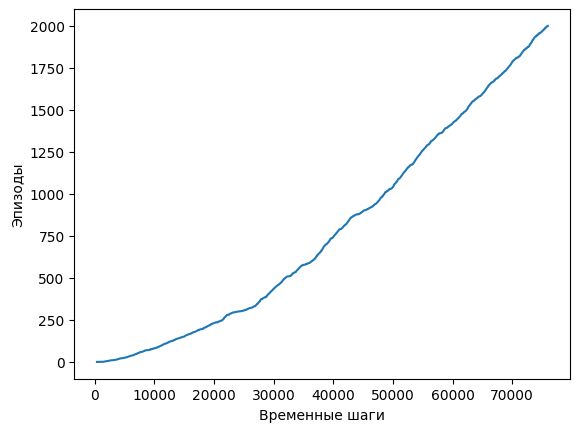

In [52]:
episode_endings = []  
cur_step = 0

for i in tqdm(range(NUM_EPISODES), desc="Эпизод"):
    cur_state = START
    action, action_idx = eps_greedy_action(Q, cur_state)
    while cur_state != GOAL:
        next_state = step(cur_state, action)
        r = -1
        next_action, next_action_idx = eps_greedy_action(Q, next_state)
        Q[cur_state[0], cur_state[1], action_idx] += ALPHA*(
            r + GAMMA*Q[next_state[0], next_state[1], next_action_idx]
            - Q[cur_state[0], cur_state[1], action_idx]
        )
        cur_state = next_state
        action = next_action
        action_idx = next_action_idx
        cur_step += 1
    episode_endings.append(cur_step)

plt.plot(episode_endings, np.arange(1, NUM_EPISODES + 1))
plt.xlabel("Временные шаги")
plt.ylabel("Эпизоды")
plt.show()

Длина одной жадной траектории: 12 шагов
Средняя длина по 100 прогонам: 16.4 ± 9.1 шагов


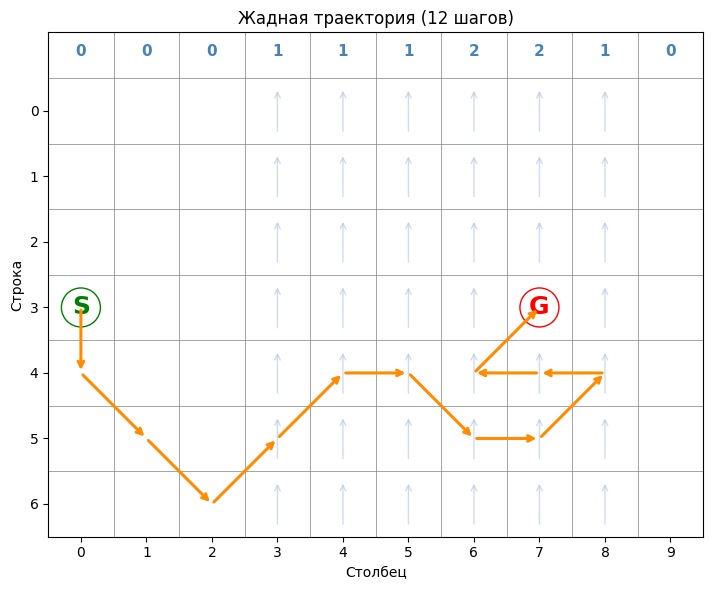

In [53]:
def greedy_trajectory(Q, start, goal, max_steps=500):
    path = [start]
    cur_state = start
    for _ in range(max_steps):
        if cur_state == goal:
            break
        action, _ = greedy_action(Q, cur_state)
        cur_state = step(cur_state, action)
        path.append(cur_state)
    return path

path = greedy_trajectory(Q, START, GOAL)
print(f"Длина одной жадной траектории: {len(path) - 1} шагов")

lengths = [len(greedy_trajectory(Q, START, GOAL)) - 1 for _ in range(100)]
print(f"Средняя длина по 100 прогонам: {np.mean(lengths):.1f} ± {np.std(lengths):.1f} шагов")

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -1.2)
ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
ax.set_xticks(range(COLS))
ax.set_yticks(range(ROWS))
ax.grid(which='minor', color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.tick_params(which='minor', length=0)

for c, w in enumerate(WIND):
    if w > 0:
        for r in range(ROWS):
            ax.annotate('', xy=(c, r - 0.35), xytext=(c, r + 0.35),
                        arrowprops=dict(arrowstyle='->', color='lightsteelblue', alpha=0.6))

for c, w in enumerate(WIND):
    ax.text(c, -0.9, str(w), ha='center', va='center',
            fontsize=11, color='steelblue', fontweight='bold')

ax.text(START[1], START[0], 'S', ha='center', va='center',
        fontsize=18, fontweight='bold', color='green',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='green'))
ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center',
        fontsize=18, fontweight='bold', color='red',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='red'))

for i in range(len(path) - 1):
    r1, c1 = path[i]
    r2, c2 = path[i + 1]
    ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))

ax.set_title(f"Жадная траектория ({len(path) - 1} шагов)")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")
plt.tight_layout()
plt.show()